In [5]:
# =========================
# ① ライブラリ
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

# =========================
# ② データ読み込み
# =========================
dir_path = '/content/drive/MyDrive/datascience-for-beginner/archive_EV/'
df = pd.read_csv(dir_path + 'AI_Learner_EV_Dataset_Pro.csv')


In [6]:
# =========================
# ③ 外れ値除去（IQR）
# =========================
cols = ["PriceEuro", "TopSpeed_KmH", "Range_Km", "AccelSec"]  #対象の列を指定

def remove_outliers_iqr(df, cols):  #DataFrame（df）と対象列（cols）を受け取る関数を定義
    df_clean = df.copy()  #元データを壊さないためコピーを作成
    for col in cols:
        #四分位数を計算
        Q1 = df_clean[col].quantile(0.25) #Q1（第1四分位数）：小さい順に並べたときの下から25%の位置
        Q3 = df_clean[col].quantile(0.75) #Q3（第3四分位数）：下から75%の位置
        IQR = Q3 - Q1 #IQRを計算
        #外れ値の範囲を決定:この範囲を外れると「外れ値」と認定
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        #外れ値を削除:下限以上、上限以下
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean #最終結果を返す

df = remove_outliers_iqr(df, cols)

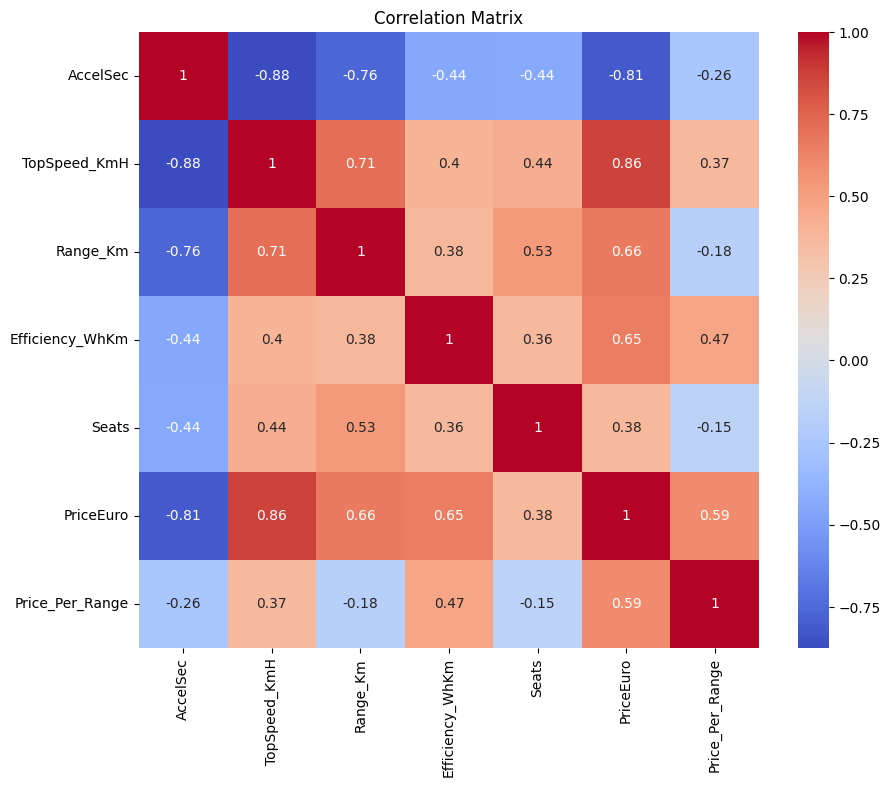

In [7]:
# =========================
# ④ 可視化（相関）
# =========================
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [8]:
# =========================
# ⑤ 特徴量エンジニアリング
# =========================
df["Performance_Index"] = df["TopSpeed_KmH"] / df["AccelSec"] #「どれだけ速く、どれだけ早く加速できるか」を同時に評価: Performance=最高速度/加速時間
df["Efficiency_Score"] = 1 / df["Efficiency_WhKm"]  #「効率が良いほど値が大きくなるように変換」

In [9]:
# =========================
# ⑥ 人気パフォーマンス作成
# =========================

#総合評価スコア:人気 = 速さ + 長距離 + 加速 + 燃費
df["Popularity_Score"] = (
    0.4 * (df["TopSpeed_KmH"] / df["TopSpeed_KmH"].max()) + #最高速度 → 40%
    0.3 * (df["Range_Km"] / df["Range_Km"].max()) + #航続距離 → 30%
    0.2 * ((1 / df["AccelSec"]) / (1 / df["AccelSec"]).max()) + #加速 → 20%
    0.1 * ((1 / df["Efficiency_WhKm"]) / (1 / df["Efficiency_WhKm"]).max()) #効率 → 10%
)
#スコアを順位に変換
df["Popularity_Rank"] = df["Popularity_Score"].rank(ascending=False)

In [10]:
# =========================
# ⑦ 特徴量選択
# =========================

#モデルに入力する説明変数（X）を定義
features = [
    "TopSpeed_KmH",
    "Range_Km",
    "AccelSec",
    "Price_Per_Range",
    "Performance_Index"
]

X = df[features]  #入力データ（X）
y = np.log1p(df["PriceEuro"]) #目的変数（y）

In [11]:
# =========================
# ⑧ 標準化（SVR用）
# =========================
#SVR（サポートベクター回帰）用にデータのスケールを揃える処理
#できるだけ誤差を小さくしつつ、シンプルな関数で予測する回帰モデル
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  #fit（学習）:各列の平均と標準偏差を計算 + transform（変換）:スケール変換

In [12]:
# =========================
# ⑨ モデル定義
# =========================

#どのモデルで学習するかをまとめて定義して比較
models = {
    "Ridge": Ridge(alpha=1.0),  #Ridge（リッジ回帰）複雑になりすぎないよう制限
    "SVR": SVR(kernel="rbf", C=10), #サポートベクター回帰（Support Vector Regression）
    "LightGBM": LGBMRegressor(  #LightGBM
        n_estimators=100, #「木」の数
        max_depth=3,  #木の深さ
        learning_rate=0.05  #学習の慎重さ
    )
}

In [13]:
# =========================
# ⑩ CV(Cross Validation)評価
# =========================

#3つのモデル（Ridge / SVR / LightGBM）のうち一番適したモデルを順番に評価
print("=== Cross Validation ===")
for name, model in models.items():

    if name == "SVR":
        scores = cross_val_score(model, X_scaled, y,  #クロスバリデーションでモデルを評価
                                 cv=5,  #Cross Validation=5回テストして平均を取る
                                 scoring="neg_root_mean_squared_error") #RMSE:予測のズレの大きさ
    else:
        scores = cross_val_score(model, X, y,
                                 cv=5,
                                 scoring="neg_root_mean_squared_error")

    print(f"{name} RMSE:", -scores.mean())

=== Cross Validation ===
Ridge RMSE: 0.08158672501930327
SVR RMSE: 0.09260377143262379
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000019 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 105
[LightGBM] [Info] Number of data points in the train set: 73, number of used features: 5
[LightGBM] [Info] Start training from score 10.670894
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

In [14]:
# =========================
# ⑪ 最終モデル（Ridge）
# =========================

#CV評価の結果LightGBM RMSE: 0.17365429545163064, Ridge RMSE: 0.08158672501930327、SVR RMSE: 0.09260377143262379
#のためRMSEが一番低いRidgeがベストなモデルと判定
#データを 学習用80% / 検証用20% に分ける
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train) #特徴量 → 価格（log） の関係を学習

pred = model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(
    np.expm1(y_valid),
    np.expm1(pred)
))

print("\nFinal RMSE:", rmse)


Final RMSE: 2484.3178318691034


In [15]:
# =========================
# ⑫ 全データで価格予測
# =========================
df["PredictedPrice"] = np.expm1(model.predict(X))

In [16]:
# =========================
# ⑬ コスパ指標
# =========================
df["Value_Score"] = df["Popularity_Score"] / df["PredictedPrice"]

In [17]:
# =========================
# ⑭ 結果表示
# =========================
result = df[[
    "Brand",
    "Model",
    "PriceEuro",
    "PredictedPrice",
    "Popularity_Score",
    "Popularity_Rank",
    "Value_Score"
]].sort_values("Popularity_Rank")

print("\n=== 人気ランキング TOP10 ===")
print(result.head(10))

print("\n=== コスパ最強 TOP10 ===")
print(df.sort_values("Value_Score", ascending=False)[[
    "Model", "Value_Score"
]].head(10))


=== 人気ランキング TOP10 ===
       Brand                           Model  PriceEuro  PredictedPrice  \
36    Lucid                             Air      105000   109410.571160   
72    Tesla              Model X Performance     102990    90869.364909   
5     Tesla               Model S Long Range      79990    83901.634473   
38  Porsche                   Taycan 4S Plus     109302   108848.245163   
70    Tesla   Model Y Long Range Performance      65620    62914.090640   
65    Tesla               Model X Long Range      85990    85717.695030   
9     Tesla    Model 3 Long Range Dual Motor      55480    60783.056868   
3   Porsche                        Taycan 4S     102945   103495.666480   
52      BMW                              i4       65000    66630.435830   
88    Tesla    Model Y Long Range Dual Motor      58620    60924.485078   

    Popularity_Score  Popularity_Rank  Value_Score  
36          0.985000              1.0     0.000009  
72          0.887227              2.0     0.0

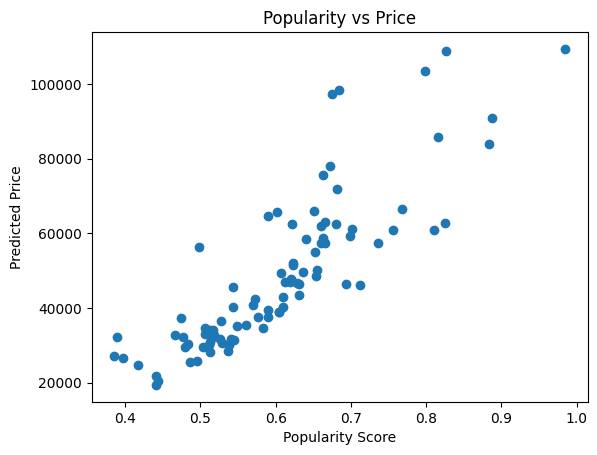

In [18]:
# =========================
# ⑮ 可視化① 人気 vs 価格
# =========================
plt.scatter(df["Popularity_Score"], df["PredictedPrice"])
plt.xlabel("Popularity Score")
plt.ylabel("Predicted Price")
plt.title("Popularity vs Price")
plt.show()

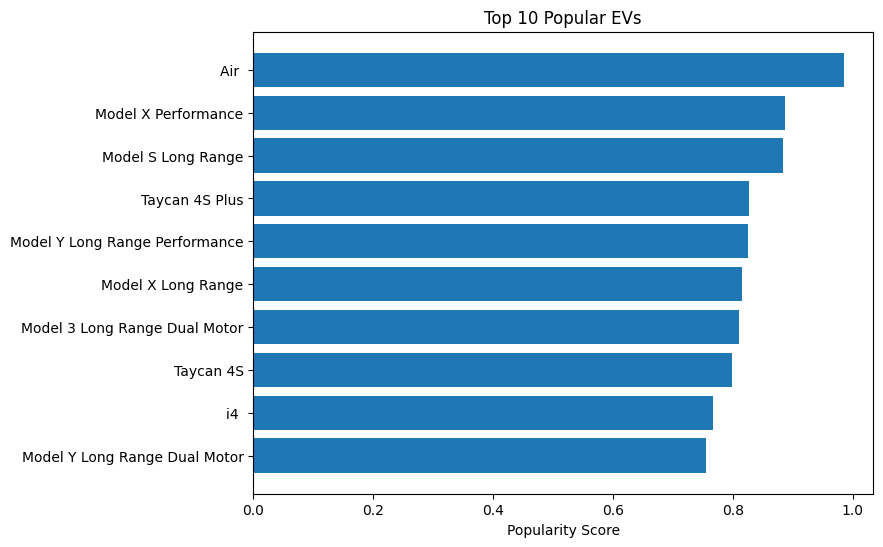

In [19]:
# =========================
# ⑯ 可視化② 人気TOP10
# =========================
top10 = result.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["Model"], top10["Popularity_Score"])
plt.title("Top 10 Popular EVs")
plt.xlabel("Popularity Score")
plt.gca().invert_yaxis()
plt.show()

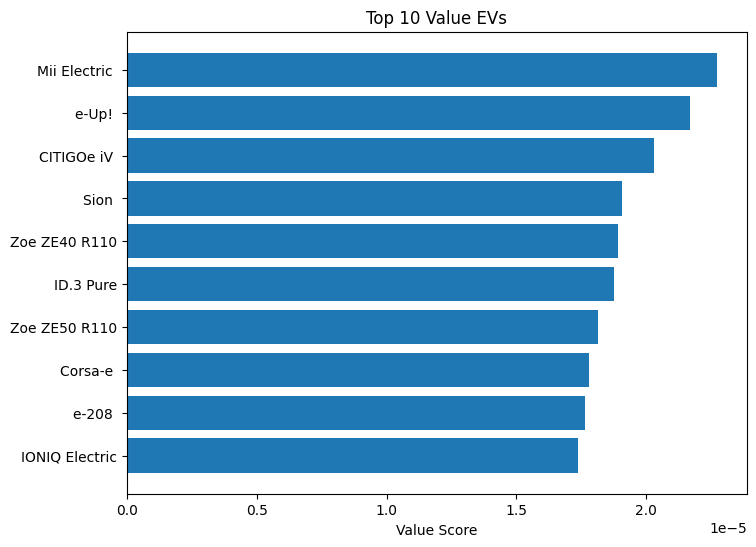

In [20]:
# =========================
# ⑰ 可視化③ コスパTOP10
# =========================
value_top10 = df.sort_values("Value_Score", ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.barh(value_top10["Model"], value_top10["Value_Score"])
plt.title("Top 10 Value EVs")
plt.xlabel("Value Score")
plt.gca().invert_yaxis()
plt.show()

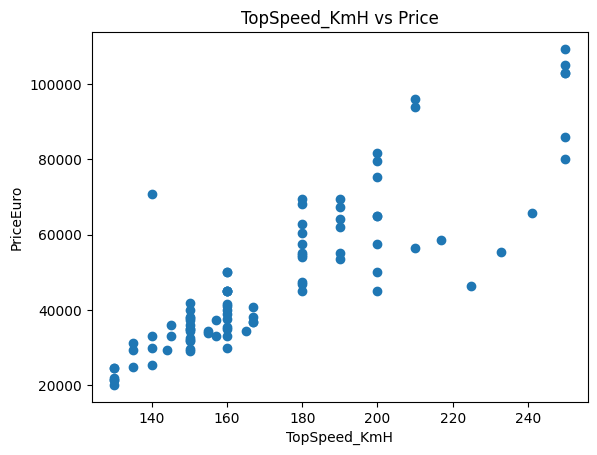

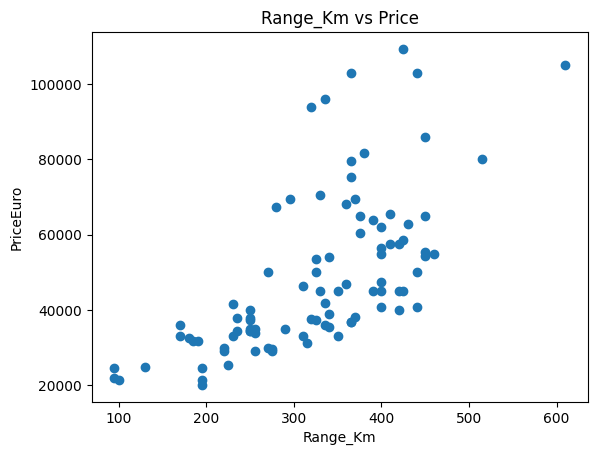

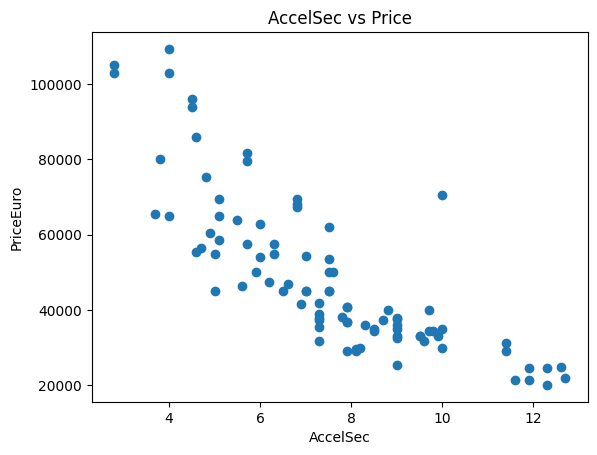

In [21]:
# =========================
# ⑱ 可視化④ 価格 vs 性能
# =========================

features = ["TopSpeed_KmH", "Range_Km", "AccelSec"]

for col in features:
    plt.scatter(df[col], df["PriceEuro"])
    plt.xlabel(col)
    plt.ylabel("PriceEuro")
    plt.title(f"{col} vs Price")
    plt.show()

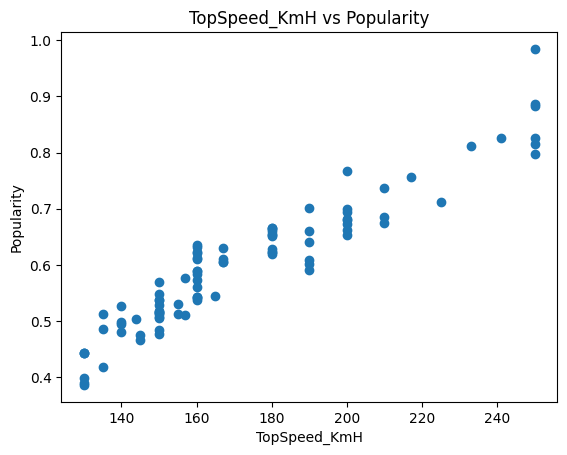

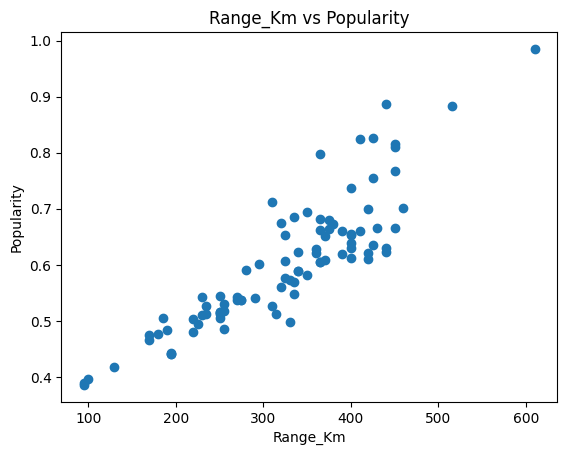

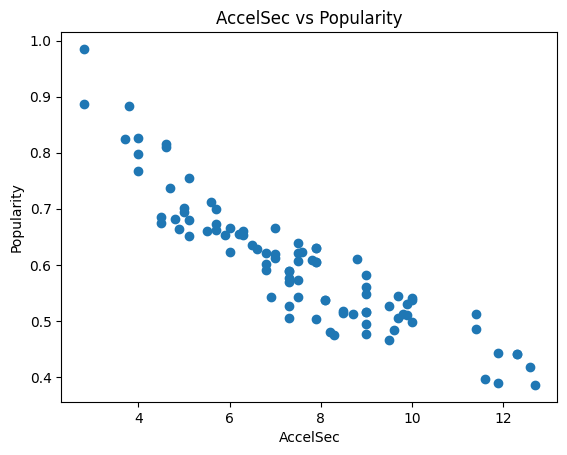

In [22]:
# =========================
# ⑲ 可視化⑤ 人気 vs 性能
# =========================

for col in features:
    plt.scatter(df[col], df["Popularity_Score"])
    plt.xlabel(col)
    plt.ylabel("Popularity")
    plt.title(f"{col} vs Popularity")
    plt.show()

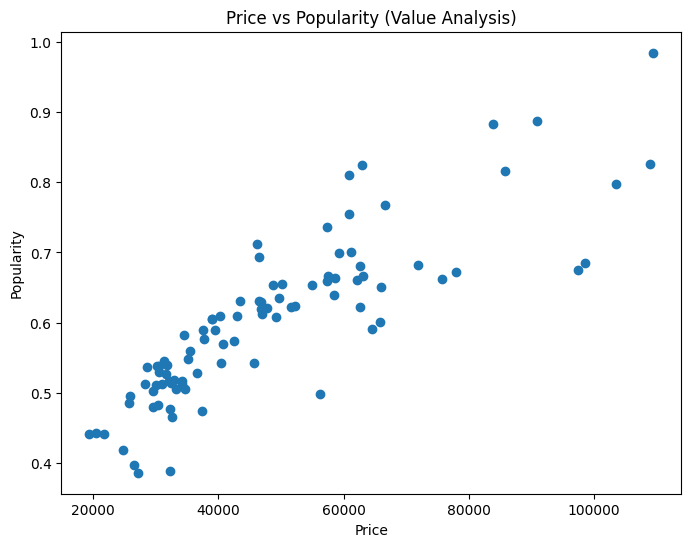

In [23]:
# =========================
# ⑳ 可視化⑥ コスパ
# =========================

plt.figure(figsize=(8,6))

plt.scatter(df["PredictedPrice"], df["Popularity_Score"])

plt.xlabel("Price")
plt.ylabel("Popularity")
plt.title("Price vs Popularity (Value Analysis)")

plt.show()

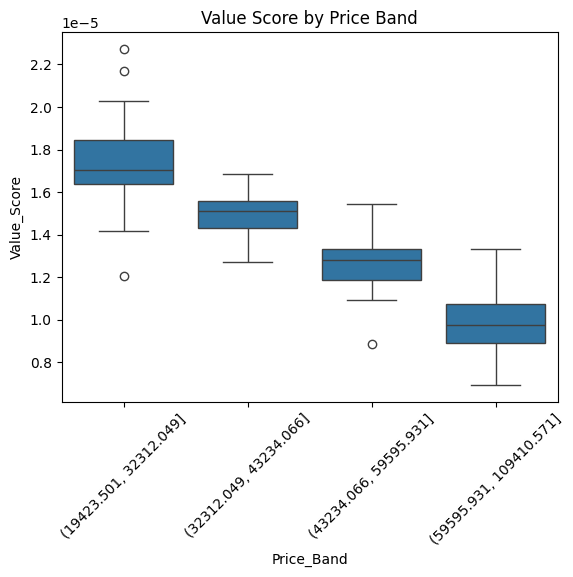

In [24]:
# =========================
# ㉑ 可視化⑦ 価格帯別コスパ
# =========================

df["Price_Band"] = pd.qcut(df["PredictedPrice"], 4)

sns.boxplot(x="Price_Band", y="Value_Score", data=df)
plt.xticks(rotation=45)
plt.title("Value Score by Price Band")
plt.show()

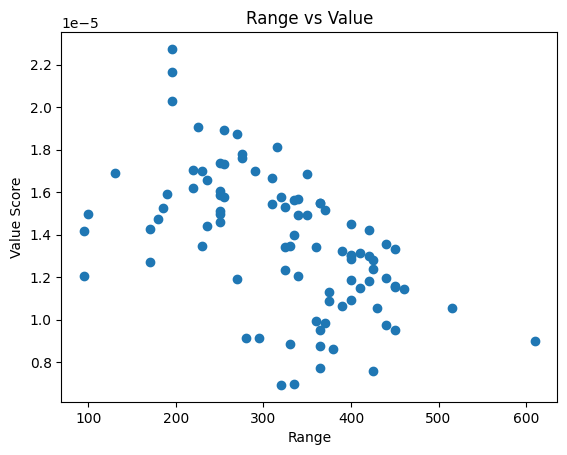

In [25]:
# =========================
# ㉒ 可視化⑧ コスパ vs 性能
# =========================

plt.scatter(df["Range_Km"], df["Value_Score"])
plt.xlabel("Range")
plt.ylabel("Value Score")
plt.title("Range vs Value")
plt.show()